In [1]:
%matplotlib inline
from sotodlib import core
import numpy as np
import matplotlib.pyplot as plt
import h5py
import so3g
import so3g.proj.quat as quat

from quat_plot import *

DEG = np.pi / 180
pi = np.pi
ARCMIN = DEG/60
ARCSEC = DEG/60


#define random offsets
#azel_offset_placehold = np.random.randint(-3,high=3, size=2)#+np.random.rand(2)
#fp_offset_placehold = np.random.randint(2,5,size=2)

In [2]:

DEG = np.pi/180.
nom_path=''
nomdataset= 'focal_plane.h5'

In [3]:
ufms= ['ufm_mv19','ufm_mv18','ufm_mv22','ufm_mv29','ufm_mv7','ufm_mv9','ufm_mv15']


In [4]:
centers=np.array([[ 0.   , 0.   ,  0.   ],
                  [ 0.   , -0.221,  0.   ],
                  [-0.191, -0.111,  0.   ],
                  [-0.191,  0.111,  0.   ],
                  [ 0.   ,  0.221,  0.   ],
                  [ 0.191,  0.111,  0.   ],
                  [ 0.191, -0.111,  0.   ]])

In [5]:
names = ['w0', 'w1', 'w2',
         'w3', 'w4','w5','w6']
boresight_angle=0
fp_centers = so3g.proj.FocalPlane.from_xieta(names, xi=centers[:,0], eta=centers[:,1])

rot_centers = np.asarray([quat.decompose_xieta(quat.euler(2,-boresight_angle*DEG)*fp_centers[fpq]) for fpq in fp_centers])

TypeError: Incompatible Data Type

In [12]:
fp_centers

FocalPlane([('w0', spt3g.core.quat(1,0,0,0)),
            ('w1', spt3g.core.quat(0.993799,0,0.111189,0)),
            ('w2', spt3g.core.quat(0.993804,-0.0960954,0.055846,0)),
            ('w3', spt3g.core.quat(0.993804,-0.0960954,-0.055846,0)),
            ('w4', spt3g.core.quat(0.993799,1.36168e-17,-0.111189,0)),
            ('w5', spt3g.core.quat(0.993804,0.0960954,-0.055846,0)),
            ('w6', spt3g.core.quat(0.993804,0.0960954,0.055846,0))])

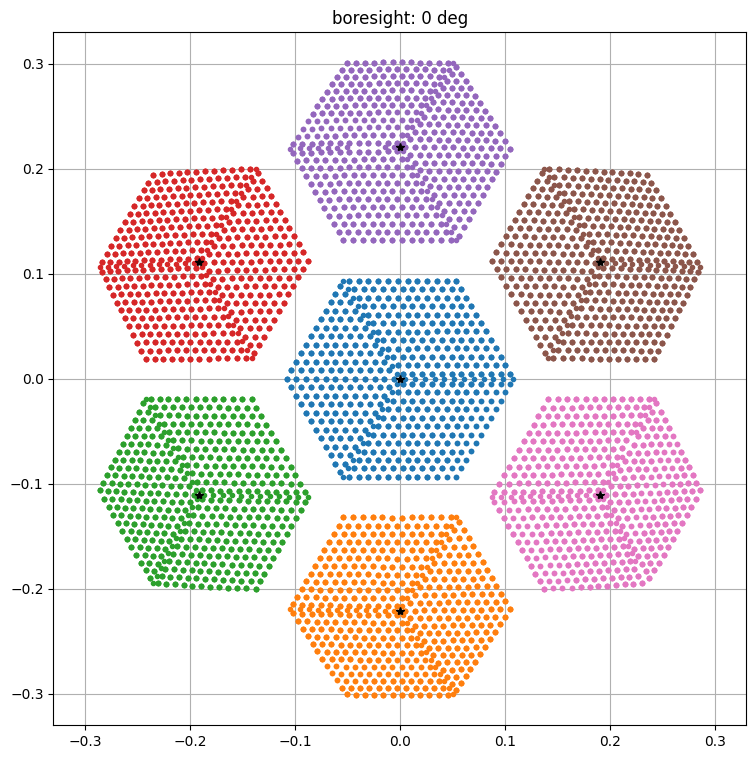

In [20]:
# Plotting in Xi Eta coordinates

fig = plt.figure(figsize=(9,9))
gs = fig.add_gridspec(3, 3)
ax = fig.add_subplot(gs[:,:],aspect='equal')
ax.grid()

with h5py.File(nom_path+nomdataset,'r') as hdf:
    for ufm in ufms:
        rx = hdf[ufm]
        wafer_q = so3g.proj.FocalPlane.from_xieta(rx['dets:det_id'], xi=rx['xi'], eta=rx['eta'])
        rx = np.asarray([quat.decompose_xieta( quat.euler(2, -boresight_angle * DEG)\
                                              * wafer_q[fpq]) for fpq in wafer_q ])
        ax.plot(rx[:,0], rx[:,1],'.')
        
#plot nominal center of wafers and edges
ax.plot(rot_centers[:,0], rot_centers[:,1],'*k')
#ax.plot(rot_centers[:,0]+0.095, rot_centers[:,1],'<k')
#ax.plot(rot_centers[:,0]-0.095, rot_centers[:,1],'>k')

ax.set_ylim(-0.33, 0.33)
ax.set_xlim(-0.33, 0.33)
plt.title(f'boresight: {boresight_angle} deg')
plt.show()

In [36]:
quat.rotation_lonlat?

Signature: quat.rotation_lonlat(lon, lat, psi=0.0)
Docstring:
Returns the quaternion that composes the Euler rotations:
    
    Qz(lon) Qy(pi/2 - lat) Qz(psi)

Note arguments are in radians.
File:      ~/.local/lib/python3.10/site-packages/so3g/proj/quat.py
Type:      function

# Quaternion rotations change the definition of the reference frames.  
## At first the fp_centers are defined as xieta quats, where z axis is into the page, at the center of the center wafer. 

## You could apply a rotation at this point, and it would represent the roatation of the focal plane about the boresight axis of the telescope.

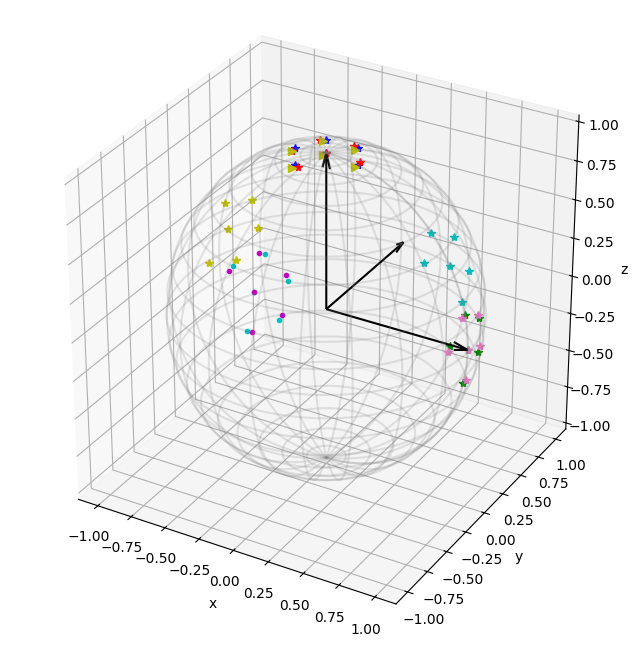

In [85]:
names = ['w0', 'w1', 'w2',
         'w3', 'w4','w5'] #,'w6']
boresight_angle=0
fp_centers = so3g.proj.FocalPlane.from_xieta(names, xi=centers[:-1,0], eta=centers[:-1,1])
#exclude ws6 so you can see rotations better.

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect((1,1,1))
plot_sphere_grid(ax)

A = 90
E = 45
lonlat_ws0 = quat.rotation_lonlat(-A*DEG, E*DEG) #rotation that points center wafer to Az = A and El = E
lonlat00 = quat.rotation_lonlat(0,0)


for i,q in enumerate(fp_centers):
    ## This first plot shows the fp centers tacked onto the z-axis pointing straight north.
    plot_from_q(ax, fp_centers[q],label='',color = 'b', marker='*')
    
    ## Now we can rotate the focal plane about the boresight axis, as if the installation was physically wonky.
    plot_from_q(ax, quat.euler(2, 10*DEG)*fp_centers[q],
                label='',color = 'r', marker='*')
    
    #You could also pretend you had an overall shift of the focal plane.
    plot_from_q(ax, quat.rotation_xieta(2*DEG,0)*fp_centers[q],
                label='',color = 'y', marker='>')    
    
    ## Demonstrate that the lonlat quat rotation changes the reference frame. az=0, el=0 points straight north
    plot_from_q(ax, quat.rotation_lonlat(0,0)*fp_centers[q],
                label='',color = 'g', marker='*')
    plot_from_q(ax, quat.rotation_lonlat(0,0)*quat.euler(2, 10*DEG)*fp_centers[q],
                label='',color = 'C6', marker='*')
    
    ## lonlat rotate to (0,90deg) takes pointing back to zenith
    #plot_from_q(ax, quat.rotation_lonlat(0,np.pi/2)*fp_centers[q],label='',color = 'm', marker='*')
    
    ## Point boresight to (az,el)  = (0,45)
    plot_from_q(ax, quat.rotation_lonlat(0,30*DEG)*fp_centers[q],
                label='',color = 'c', marker='*')
    
    ## Point to (90,45)
    plot_from_q(ax, quat.rotation_lonlat(-90*DEG, 30*DEG)*fp_centers[q],
                label='',color = 'c', marker='.')
    plot_from_q(ax, quat.rotation_lonlat(-90*DEG, 30*DEG)*quat.euler(2, 10*DEG)*fp_centers[q],
                label='',color = 'm', marker='.')
    
    ## applying an euler rotation about z axis after a lonlat rotation no longer rotates about boresight
    plot_from_q(ax, quat.euler(2, -27*DEG)*lonlat_ws0*fp_centers[q],label='',color = 'y', marker='*')
    
    
#plt.legend(ncols = 7)

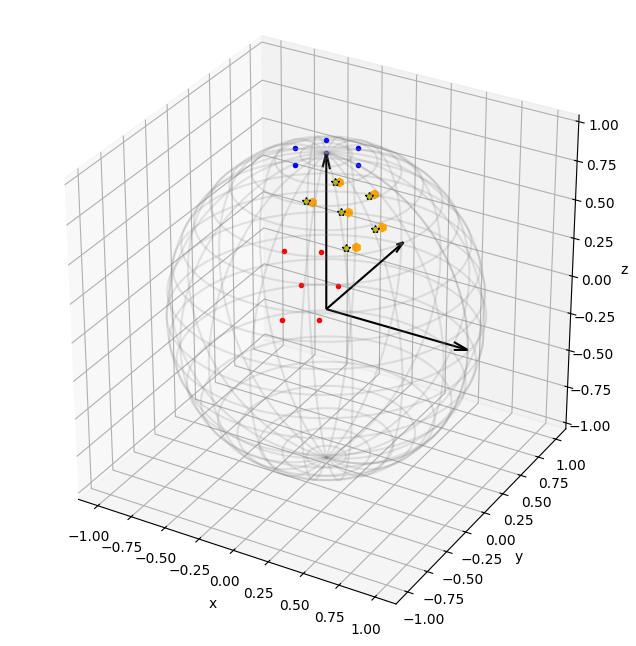

In [101]:
names = ['w0', 'w1', 'w2',
         'w3', 'w4','w5'] #,'w6']
boresight_angle=0
fp_centers = so3g.proj.FocalPlane.from_xieta(names, xi=centers[:-1,0], eta=centers[:-1,1])
#exclude ws6 so you can see rotations better.

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect((1,1,1))
plot_sphere_grid(ax)

A = 90
E = 45
lonlat_ws0 = quat.rotation_lonlat(-A*DEG, E*DEG) #rotation that points center wafer to Az = A and El = E
lonlat00 = quat.rotation_lonlat(0,0)


for i,q in enumerate(fp_centers):

    
    ## Point to (90,45)
    plot_from_q(ax, quat.rotation_lonlat(-45*DEG, 60*DEG)*fp_centers[q],
                label='',color = 'orange', marker='h')
    
    #what happens when you apply the same two lonlat rotations in a row?
    plot_from_q(ax, quat.rotation_lonlat(-45*DEG, 60*DEG)\
                    *quat.rotation_lonlat(-45*DEG, 60*DEG)*fp_centers[q],
                label='',color = 'r', marker='.')
    #If you want to go back where you started, you have to do an inverse rotation ~
    plot_from_q(ax, quat.rotation_lonlat(-45*DEG, 60*DEG)\
                    *~quat.rotation_lonlat(-45*DEG, 60*DEG)*fp_centers[q],
                label='',color = 'b', marker='.')
    #If you are modeleing an az offset, you either would use an euler rotation
    # Or add it to the az value in the lon lat, you don't do an extra lonlat rotation.
    
    plot_from_q(ax, quat.rotation_lonlat(- (45*DEG + 5*DEG), 60*DEG)*fp_centers[q],
                label='',color = 'k', marker='*')    
    plot_from_q(ax, quat.euler(2,-5*DEG)*quat.rotation_lonlat(- (45*DEG), 60*DEG)*fp_centers[q],
                label='',color = 'y', marker='.',ms=5)       
    
#plt.legend(ncols = 7)